# Predictive Maintenance วิเคราะห์ความสั่นสะเทือนเครื่องจักรด้วย Python (Part 1)
### 🌟 บทนำ (Introduction)

ในวงการอุตสาหกรรม "เครื่องจักรพังกระทันหัน" คือฝันร้ายที่นำไปสู่ความสูญเสียทั้งเวลาและต้นทุนมหาศาล โปรเจกต์นี้จึงเกิดขึ้นมาเพื่อตอบคำถามที่ว่า "เราจะรู้ล่วงหน้าได้อย่างไรว่าเครื่องจักรใกล้จะพัง?"

คำตอบคือการฟังเสียงกระซิบจากเครื่องจักรผ่าน "ความสั่นสะเทือน (Vibration)" ครับ ในโปรเจกต์นี้ เราจะสร้างระบบ Predictive Maintenance โดยนำข้อมูลความสั่นสะเทือนของเครื่องจักรหมุน (เช่น ปั๊มน้ำ, คอมเพรสเซอร์) มาวิเคราะห์เทียบกับเกณฑ์มาตรฐานระดับโลกอย่าง ISO 10816-3 เป้าหมายของเราคือการจัดระดับความรุนแรง (Zone A สีเขียว ไปจนถึง Zone D สีแดง) และที่สำคัญที่สุดคือ การพยากรณ์ล่วงหน้า (Trend Prediction) ว่าเครื่องจักรตัวนี้จะเสื่อมสภาพจนถึงจุดอันตรายเมื่อไหร่!

![ISO-10816-3](images/ISO-10816-3.png)

### 📊 หน้าตาของข้อมูลดิบ (The Raw Data Problem)
ข้อมูลดิบที่ได้มาจากเซนเซอร์ ถูกเก็บในรูปแบบไฟล์ .txt แบ่งตามเครื่องจักรและเดือน (เช่น มิ.ย., ก.ย., ต.ค.) โดยมีข้อมูลหลักคือ Time stamp (mS) และ Amplitude (G-s)

แต่ปัญหาแรกที่พบคือ ซอฟต์แวร์เครื่องมือวัดในโรงงานมักจะส่งออกไฟล์ .txt แบบประหยัดพื้นที่ โดยการพับทบข้อมูลเป็น 4 คอลัมน์คู่ เหมือนการจัดหน้าหนังสือพิมพ์ หน้าตาเป็นแบบนี้:
```
Time (mS) Amplitude Time (mS) Amplitude Time (mS) Amplitude Time (mS) Amplitude
--------- --------- --------- --------- --------- --------- --------- ---------
       0.      .267     133.3      .086     266.7     -.226     400.0      .014
     .130     -.399     133.5     -.606     266.8     -.028     400.1      .602
```
หากสังเกตให้ดี ข้อมูลไม่ได้เรียงลำดับเวลาจากซ้ายไปขวา แต่เรียง "จากบนลงล่างทีละคอลัมน์" (ตัวอย่างเช่น คอลัมน์แรกเริ่ม 0 ถึง 133.2 mS จากนั้นคอลัมน์ที่สองค่อยมารับช่วงต่อที่ 133.3 mS)

#### Install dependency

In [40]:
!pip3 install -q pandas
!pip3 install -q scipy
!pip3 install -q matplotlib
!pip3 install -q seaborn
!pip3 install -q scikit-learn


## 🛠️ Step 1: การดึงข้อมูลและทำความสะอาด (Data Extraction & Cleaning)
เพื่อให้นำไปวิเคราะห์ต่อได้ง่าย จะต้องเขียนโค้ด Python ทะลวงเข้าไปอ่านไฟล์นี้ ข้ามส่วน Header กวาดข้อมูลทั้งหมดมาต่อกัน และที่สำคัญที่สุดคือ ต้องทำความสะอาดและเรียงลำดับเวลาใหม่ทั้งหมด เพื่อไม่ให้การคำนวณทางคณิตศาสตร์ในขั้นตอนต่อไปผิดเพี้ยน

#### 💻 โค้ดสำหรับดึงรายชื่อ Equipment ทั้งหมด

In [22]:
import os
import glob

def find_unique_equipments(folder_path):
    """
    กวาดอ่านทุกไฟล์ในโฟลเดอร์เพื่อหาชื่อ Equipment ที่ไม่ซ้ำกัน
    """
    unique_names = set() # ใช้ set เพื่อเก็บเฉพาะชื่อที่ไม่ซ้ำ
    
    # หาไฟล์ .txt ทั้งหมดในโฟลเดอร์
    filepaths = glob.glob(os.path.join(folder_path, '*.txt'))
    
    for filepath in filepaths:
        with open(filepath, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                if line.startswith("Equipment:"):
                    # ตัดเอาเฉพาะชื่อที่อยู่หลังคำว่า Equipment:
                    raw_name = line.split("Equipment:")[1].strip()
                    unique_names.add(raw_name)
                    
    return sorted(list(unique_names)) # แปลงกลับเป็น List และเรียงตามตัวอักษร

# ==========================================
# 🎯 ทดสอบการใช้งาน
# ==========================================
folder = './raw-data'
all_equipments = find_unique_equipments(folder)

print("🔍 สรุปรายชื่อ Equipment ทั้งหมดที่พบ:")
print("-" * 40)
for name in all_equipments:
    # พิมพ์ออกมาในรูปแบบที่ก๊อปปี้ไปใส่ Dictionary ได้ง่ายๆ
    print(f'"{name}": "",')
print("-" * 40)
print(f"รวมทั้งหมด {len(all_equipments)} ชื่อ")

🔍 สรุปรายชื่อ Equipment ทั้งหมดที่พบ:
----------------------------------------
"(CHPP) Cooling Pump for ECH-02": "",
"(CHPP) Cooling Pump for OAH-02": "",
"(CHPP) Motor Compressor CH-06_A": "",
"Cooling Pump for OAH-02": "",
"Jockey Pump": "",
"Motor Compressor OAH-06_A": "",
----------------------------------------
รวมทั้งหมด 6 ชื่อ


#### 💻 Python Code สำหรับ Data Parsing

สามารถใช้ ```pandas``` ในการจัดการโครงสร้างข้อมูล และเพิ่มขั้นตอนการทำ Data Cleaning (ลบค่าว่าง, ลบเวลาซ้ำ, เรียงลำดับเวลา) เข้าไปในฟังก์ชันเดียวเลย:

In [29]:
import pandas as pd
import os
import glob

# ==========================================
# 🛠️ 1. สร้าง Dictionary แก้ปัญหาชื่อเครื่องจักรไม่ตรงกัน
# ==========================================
# ==========================================
# 🛠️ 1. สร้าง Dictionary (อัปเดตจากข้อมูลจริง 6 ชื่อ)
# ==========================================
equipment_map = {
    # กลุ่มที่ 1: Cooling Pump ECH-02
    "(CHPP) Cooling Pump for ECH-02": "Cooling Pump ECH-02",
    
    # กลุ่มที่ 2: Cooling Pump OAH-02
    "(CHPP) Cooling Pump for OAH-02": "Cooling Pump OAH-02",
    "Cooling Pump for OAH-02": "Cooling Pump OAH-02",
    
    # กลุ่มที่ 3: Compressor 06_A
    "(CHPP) Motor Compressor CH-06_A": "Compressor 06_A",
    "Motor Compressor OAH-06_A": "Compressor 06_A",
    
    # กลุ่มที่ 4: Jockey Pump (ชื่อเดียวไม่มีตัวซ้ำ)
    "Jockey Pump": "Jockey Pump"
}

# ==========================================
# 🚀 2. ฟังก์ชันหลักสำหรับดึงข้อมูล
# ==========================================
def parse_and_clean_vibration_data(filepath):
    data_list = []
    current_equipment = "Unknown"
    current_date = "Unknown"
    
    with open(filepath, 'r', encoding='utf-8') as file:
        lines = file.readlines()
        
    # --- ขั้นตอนที่ A: ดึง Metadata (ชื่อเครื่องจักร และ วันที่) จาก Header ---
    for line in lines:
        line = line.strip()
        if line.startswith("Equipment:"):
            raw_name = line.split("Equipment:")[1].strip()
            # แปลงชื่อให้เป็นมาตรฐานตาม Dictionary ถ้าหาไม่เจอให้ใช้ชื่อเดิม
            current_equipment = equipment_map.get(raw_name, raw_name)
            
        elif line.startswith("Date/Time:"):
            # ดึงแค่วันที่ ตัดคำว่า Amplitude หรือเวลาทิ้งไป
            dt_part = line.split("Amplitude:")[0].replace("Date/Time:", "").strip()
            current_date = dt_part.split()[0] # ผลลัพธ์จะได้เช่น "04-Sep-24"
            break # ได้ข้อมูล Header ครบแล้ว หยุดหา
            
    # --- ขั้นตอนที่ B: หาตำแหน่งเริ่มข้อมูลตัวเลข ---
    start_idx = 0
    for i, line in enumerate(lines):
        if '---------' in line:
            start_idx = i + 1
            break
            
    # --- ขั้นตอนที่ C: กวาดข้อมูล Time และ Amplitude ---
    for line in lines[start_idx:]:
        parts = line.split()
        
        # วนลูปทีละ 2 ค่า ในแต่ละบรรทัด
        for i in range(0, len(parts), 2):
            if i + 1 < len(parts):
                try:
                    time_ms = float(parts[i])
                    amplitude = float(parts[i+1])
                    
                    # เก็บข้อมูลตัวเลข พร้อมแนบชื่อเครื่องจักรและวันที่ไปด้วย
                    data_list.append({
                        'Equipment': current_equipment,
                        'Date': current_date,
                        'Time_mS': time_ms, 
                        'Amplitude_G': amplitude
                    })
                except ValueError:
                    continue 
                    
    df = pd.DataFrame(data_list)
    
    # --- ขั้นตอนที่ D: Data Cleaning ---
    if not df.empty:
        # 1. ลบค่าว่าง
        df = df.dropna(subset=['Time_mS', 'Amplitude_G'])
        
        # 2. ลบเวลาที่ซ้ำกัน (วิธีนี้จะกำจัด Data Block ที่ 2 ที่ข้อมูลซ้ำกันออกไปอัตโนมัติ)
        df = df.drop_duplicates(subset=['Time_mS'], keep='first')
        
        # 3. เรียงลำดับเวลาให้ถูกต้อง
        df = df.sort_values(by='Time_mS')
        df = df.reset_index(drop=True)
        
    return df

# ==========================================
# 🎯 3. ทดสอบการใช้งาน
# ==========================================
file_path = './raw-data/A_CH-06 A_NAA_1490__Sep24.txt'
df_example = parse_and_clean_vibration_data(file_path)
print(df_example.head())

         Equipment       Date  Time_mS  Amplitude_G
0  Compressor 06_A  04-Sep-24    0.000        0.267
1  Compressor 06_A  04-Sep-24    0.130       -0.399
2  Compressor 06_A  04-Sep-24    0.260       -0.092
3  Compressor 06_A  04-Sep-24    0.391       -0.073
4  Compressor 06_A  04-Sep-24    0.521        0.032


## ⚙️ Step 2: Signal Processing
จาก Step 1 เขียนโค้ดดึงข้อมูลดิบและจัดการปัญหาข้อมูลที่ไม่สม่ำเสมอ จนได้ตารางข้อมูลความสั่นสะเทือนที่มีคอลัมน์เวลา (Time) และความเร่ง (Amplitude in G) ที่สมบูรณ์แบบแล้ว

เป้าหมายของโปรเจกต์นี้คือการนำค่าไปเทียบกับเกณฑ์มาตรฐาน ISO 10816-3 ซึ่งใช้หน่วยวัดเป็น ความเร็ว (Velocity: mm/s RMS) ไม่ใช่ความเร่ง (G) ใน Step 2 นี้ จึงต้องอาศัยหลักการทางฟิสิกส์และคณิตศาสตร์เพื่อแปลงสัญญาณ (Signal Processing) ให้ได้ค่าตัวเลข 1 ตัวที่เป็นตัวแทนความรุนแรงของเครื่องจักรในรอบนั้นๆ

🧮 คณิตศาสตร์เบื้องหลัง (The Math Behind It)
การแปลงข้อมูลจากความเร่ง (Acceleration) ไปเป็นความเร็ว (Velocity RMS) มี 4 ขั้นตอนหลัก ดังนี้:
1. แปลงหน่วยเวลา: จากมิลลิวินาที (mS) เป็นวินาที (Seconds) โดยหารด้วย 1,000
2. แปลงหน่วยความเร่ง: จากหน่วย G เป็น mm/s² (โดยค่าแรงโน้มถ่วงมาตรฐาน 1 G ≈ 9806.65 mm/s²)
3. การอินทิเกรต (Numerical Integration): ตามหลักฟิสิกส์ ความเร็วคือพื้นที่ใต้กราฟของความเร่ง ($v = \int a \, dt$) ในที่นี้จะใช้วิธีสี่เหลี่ยมคางหมู (Trapezoidal Rule) ในการคำนวณสะสมค่าความเร็วคำ
4. นวณค่า RMS (Root Mean Square): เพื่อหาค่าเฉลี่ยพลังงานความรุนแรงของสัญญาณ ด้วยสมการ:$$V_{rms} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} v_i^2}$$

In [31]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
import pandas as pd

def calculate_velocity_rms(df):
    """
    รับค่า DataFrame ที่มีคอลัมน์ 'Time_mS' และ 'Amplitude_G' 
    เพื่อคำนวณหาค่าความเร็ว Velocity RMS (mm/s)
    """
    # 1. ดึงข้อมูลออกมาเป็น Numpy Array เพื่อความรวดเร็วในการคำนวณ
    time_ms = df['Time_mS'].values
    accel_g = df['Amplitude_G'].values
    
    # 2. แปลงหน่วย (mS -> s) และ (G -> mm/s^2)
    time_s = time_ms / 1000.0
    accel_mm_s2 = accel_g * 9806.65
    
    # 3. ลบค่าเฉลี่ยความเร่ง (DC Offset Removal) ก่อนทำ Integration
    accel_mm_s2 = accel_mm_s2 - np.mean(accel_mm_s2)
    
    # 4. ทำ Numerical Integration (Acceleration -> Velocity)
    # ใช้ initial=0 เพื่อให้ได้จำนวนจุดข้อมูลเท่ากับข้อมูลตั้งต้น
    velocity_mm_s = cumulative_trapezoid(accel_mm_s2, time_s, initial=0)
    
    # 5. ลบค่าเฉลี่ยความเร็ว (DC Offset Removal) หลังทำ Integration อีกครั้ง
    velocity_mm_s = velocity_mm_s - np.mean(velocity_mm_s)
    
    # 6. หาค่า RMS (Root Mean Square)
    v_rms = np.sqrt(np.mean(velocity_mm_s**2))
    
    # ส่งคืนค่า RMS โดยปัดทศนิยม 2 ตำแหน่ง
    return round(v_rms, 2)

# ==========================================
# 🎯 ทดสอบการใช้งาน (ต่อจาก DataFrame ใน Step 1)
# ==========================================
# สมมติว่ามี df_clean ที่ได้จากฟังก์ชัน parse_and_clean_vibration_data แล้ว
rms_value = calculate_velocity_rms(df_example)
print(f"✅ ความรุนแรงการสั่นสะเทือน: {rms_value} mm/s RMS")

✅ ความรุนแรงการสั่นสะเทือน: 1.8 mm/s RMS


## 🔄 Step 3: การสร้าง Loop รวมข้อมูล (Data Aggregation)
จาก Step 1 และ Step 2 ที่ได้สร้างฟังก์ชันสำหรับดึงข้อมูลและแปลงสัญญาณความเร่งให้เป็นความเร็ว (Velocity RMS) เรียบร้อยแล้ว แต่ในการทำระบบพยากรณ์ (Predictive Maintenance) จะต้องใช้ข้อมูลประวัติย้อนหลังหลายๆ เดือนมาวิเคราะห์ร่วมกัน

ใน Step 3 นี้ จะเป็นการสร้างระบบอัตโนมัติ (Automation Loop) เพื่อให้ Python วิ่งเข้าไปกวาดอ่านไฟล์ .txt ทุกไฟล์ที่อยู่ในโฟลเดอร์ ประมวลผลทีละไฟล์ แล้วนำผลลัพธ์ที่ได้มาสรุปรวมกันเป็น "ตารางสรุปสุขภาพเครื่องจักร (Summary Table)" เพื่อเตรียมพร้อมสำหรับการสร้างกราฟหาเส้นแนวโน้มต่อไป

แนวคิดคือการใช้ไลบรารี glob เพื่อค้นหาไฟล์ทั้งหมด จากนั้นใช้ลูป for สั่งให้ฟังก์ชันจาก Step 1 และ Step 2 ทำงานซ้ำๆ จนครบทุกไฟล์ และนำค่า RMS ที่ได้มาเรียงต่อกัน

นอกจากนี้ จะมีการใช้ pd.to_datetime ของ Pandas เพื่อแปลงข้อความวันที่ (เช่น "04-Sep-24") ให้เป็นชนิดข้อมูลวันที่จริงๆ ซึ่งจะช่วยให้การเรียงลำดับเวลาและการพล็อตกราฟในอนาคตถูกต้องแม่นยำ

In [32]:
import os
import glob
import pandas as pd

def process_all_files(folder_path):
    """
    กวาดอ่านทุกไฟล์ในโฟลเดอร์ ดึงข้อมูล คำนวณ RMS และสร้างตารางสรุป
    (ต้องรันโค้ดฟังก์ชันจาก Step 1 และ Step 2 ก่อนเรียกใช้ฟังก์ชันนี้)
    """
    summary_data = []
    
    # 1. หาไฟล์ .txt ทั้งหมดในโฟลเดอร์
    filepaths = glob.glob(os.path.join(folder_path, '*.txt'))
    
    print(f"📁 พบไฟล์ทั้งหมด {len(filepaths)} ไฟล์ กำลังประมวลผล...")
    
    for filepath in filepaths:
        # 2. เรียกใช้ฟังก์ชัน Step 1: ดึงและทำความสะอาดข้อมูล
        df_clean = parse_and_clean_vibration_data(filepath)
        
        # ตรวจสอบว่ามีข้อมูลหรือไม่ (ป้องกันไฟล์ว่างหรือข้อมูลเสีย)
        if df_clean.empty:
            continue
            
        # ดึงชื่อเครื่องจักรและวันที่จากแถวแรกของตาราง
        equipment = df_clean['Equipment'].iloc[0]
        date_str = df_clean['Date'].iloc[0]
        
        # 3. เรียกใช้ฟังก์ชัน Step 2: คำนวณค่า Velocity RMS
        rms_value = calculate_velocity_rms(df_clean)
        
        # 4. เก็บผลลัพธ์ลงใน List
        summary_data.append({
            'Equipment': equipment,
            'Date': date_str,
            'Velocity_RMS': rms_value
        })
        
    # 5. แปลง List เป็น DataFrame
    df_summary = pd.DataFrame(summary_data)
    
    # 6. จัดระเบียบวันที่และการเรียงลำดับ
    if not df_summary.empty:
        # แปลงสตริงวันที่ (เช่น 04-Sep-24) ให้เป็น DateTime Object
        df_summary['Date'] = pd.to_datetime(df_summary['Date'], format='%d-%b-%y')
        
        # เรียงข้อมูลตามชื่อเครื่องจักร และตามลำดับเวลา (เก่าไปใหม่)
        df_summary = df_summary.sort_values(by=['Equipment', 'Date']).reset_index(drop=True)
        
    return df_summary

# ==========================================
# 🎯 ทดสอบการใช้งานฟังก์ชัน
# ==========================================
folder = './raw-data'
df_final_summary = process_all_files(folder)
print(df_final_summary)

📁 พบไฟล์ทั้งหมด 9 ไฟล์ กำลังประมวลผล...
             Equipment       Date  Velocity_RMS
0      Compressor 06_A 2024-06-28          2.89
1      Compressor 06_A 2024-09-04          1.80
2      Compressor 06_A 2024-10-16          1.70
3  Cooling Pump OAH-02 2024-06-28          2.67
4  Cooling Pump OAH-02 2024-09-04          2.83
5  Cooling Pump OAH-02 2024-10-16          2.70
6          Jockey Pump 2024-06-28          7.06
7          Jockey Pump 2024-09-04          5.32
8          Jockey Pump 2024-10-16          6.69


## 🛠️ Step 4: การพล็อตกราฟประเมินสุขภาพเครื่องจักร (Conservative Approach)
ใช้ไลบรารี matplotlib และ seaborn เพื่อวาดกราฟเส้นแสดงแนวโน้มค่า Velocity RMS ของเครื่องจักรแต่ละตัว พร้อมระบายสีพื้นหลังเป็น 4 โซน ตามเกณฑ์ที่เข้มงวดที่สุดของ ISO 10816-3 เพื่อความปลอดภัยสูงสุดของโรงงาน

> เนื่องจากไม่มีข้อมูลกำลังการใช้ไฟฟ้าของมอเตอร์แต่ละชนิด จึงจะใช้เกณฑ์ที่เข้มงวดที่สุดของ ISO 10816-3 เพื่อดูแนวโน้มที่แย่ที่สุด
- Machinery Groups 2 and 4
- Rated Power: 15 kW - 300 kW
- Foundation: Rigid

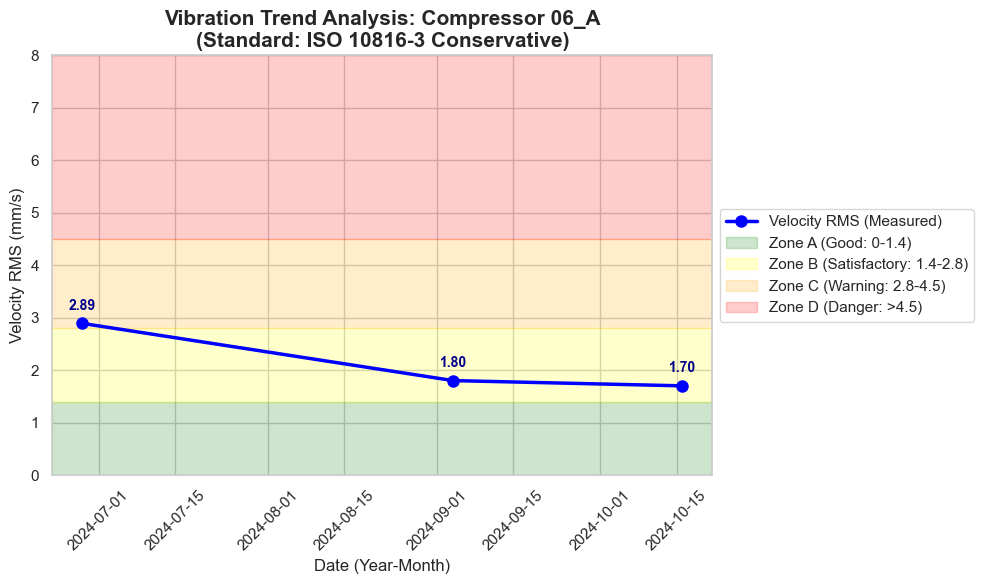

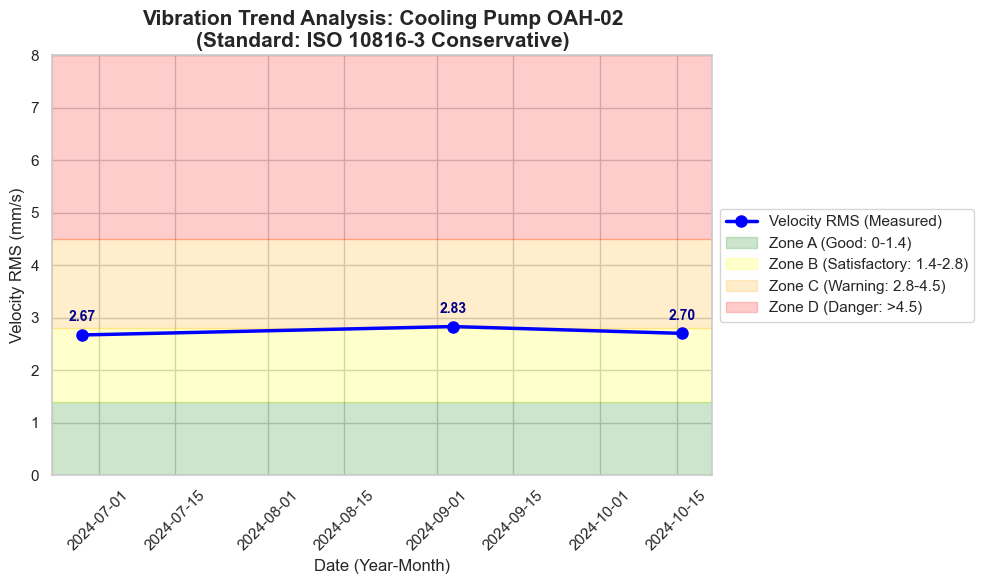

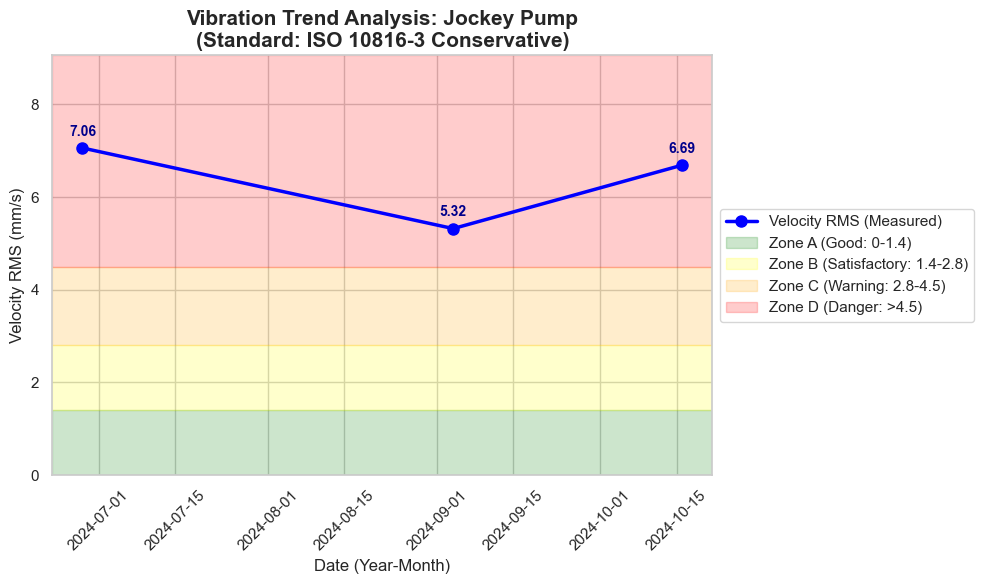

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์ของกราฟให้ดูสะอาดตา
sns.set_theme(style="whitegrid")

def plot_vibration_trend_conservative(df_summary):
    """
    พล็อตกราฟแนวโน้มความสั่นสะเทือนแยกตามเครื่องจักร 
    ใช้เกณฑ์ที่เข้มงวดที่สุด (Group 2&4 Rigid) ของ ISO 10816-3
    พร้อมใส่ตัวเลขกำกับที่จุด (Data Labels)
    """
    # ดึงรายชื่อเครื่องจักรทั้งหมดที่ไม่ซ้ำกัน
    equipments = df_summary['Equipment'].unique()
    
    # วนลูปวาดกราฟทีละเครื่อง
    for eq in equipments:
        # กรองข้อมูลเฉพาะเครื่องจักรนั้นๆ
        df_eq = df_summary[df_summary['Equipment'] == eq]
        
        plt.figure(figsize=(10, 6))
        
        # 1. พล็อตกราฟเส้น (Trend Line)
        plt.plot(df_eq['Date'], df_eq['Velocity_RMS'], 
                 marker='o', linestyle='-', linewidth=2.5, markersize=8, 
                 color='blue', label='Velocity RMS (Measured)')
        
        # 🌟 ส่วนที่เพิ่มเข้ามา: วนลูปใส่ตัวเลขกำกับที่แต่ละจุด
        for x, y in zip(df_eq['Date'], df_eq['Velocity_RMS']):
            # ใส่ข้อความ y ขยับขึ้นไปนิดหน่อย (y + 0.2) เพื่อไม่ให้ทับกับจุด
            plt.text(x, y + 0.2, f'{y:.2f}', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue')
        
        # 2. ระบายสีพื้นหลังตามเกณฑ์ ISO 10816-3 (Worst-case Scenario)
        plt.axhspan(0, 1.4, color='green', alpha=0.2, label='Zone A (Good: 0-1.4)')
        plt.axhspan(1.4, 2.8, color='yellow', alpha=0.2, label='Zone B (Satisfactory: 1.4-2.8)')
        plt.axhspan(2.8, 4.5, color='orange', alpha=0.2, label='Zone C (Warning: 2.8-4.5)')
        
        # สำหรับโซนสีแดง ให้วาดไปจนถึงขอบบนสุดของกราฟ
        max_val = df_eq['Velocity_RMS'].max()
        top_y_limit = max(8.0, max_val + 2.0) 
        plt.axhspan(4.5, top_y_limit, color='red', alpha=0.2, label='Zone D (Danger: >4.5)')
        
        # 3. ตกแต่งกราฟให้สวยงามและอ่านง่าย
        plt.title(f'Vibration Trend Analysis: {eq}\n(Standard: ISO 10816-3 Conservative)', fontsize=15, fontweight='bold')
        plt.xlabel('Date (Year-Month)', fontsize=12)
        plt.ylabel('Velocity RMS (mm/s)', fontsize=12)
        
        # เซ็ตขอบเขตแกน Y ให้ครอบคลุมโซนสี
        plt.ylim(0, top_y_limit) 
        
        # เอียงวันที่แกน X เพื่อไม่ให้ตัวหนังสือซ้อนกัน
        plt.xticks(rotation=45)
        
        # จัดตำแหน่งกล่องคำอธิบาย (Legend) ไว้ข้างนอกกราฟ
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.tight_layout()
        
        # แสดงผลกราฟ
        plt.show()

# ==========================================
# 🎯 ทดสอบการใช้งาน
# ==========================================
plot_vibration_trend_conservative(df_final_summary)

## 📈 Step 5: Trend Prediction & Machine Learning
#### 🧮 คณิตศาสตร์เบื้องหลัง (How Regression Works)
Linear Regression คือการหาสมการเส้นตรง $y = mx + c$ ที่ลากผ่านกลุ่มข้อมูลได้ดีที่สุด โดย:$y$ คือ ค่าความสั่นสะเทือน (Velocity RMS)$x$ คือ วันที่ (แปลงเป็นตัวเลขเพื่อคำนวณ)$m$ คือ ความชัน (Slope) ที่บอกว่าเครื่องจักรแย่ลงเร็วแค่ไหน$c$ คือ จุดตัดแกน (Intercept)เมื่อเราได้สมการมาแล้ว เราแค่นำค่าเกณฑ์อันตราย (เช่น $y = 4.5$) ไปแทนในสมการ แล้วแก้สมการหาค่า $x$ (วันที่) เราก็จะได้ "วันที่คาดว่าจะพัง (Predicted Failure Date)"

เราจะใช้ไลบรารี scikit-learn สำหรับทำ Linear Regression และนำโค้ดกราฟจาก Step 4 มาต่อยอดให้ลากเส้นพยากรณ์ (เส้นประ) ล่วงหน้าไปจนถึงจุดที่เครื่องจะพัง (ดาวสีแดง)

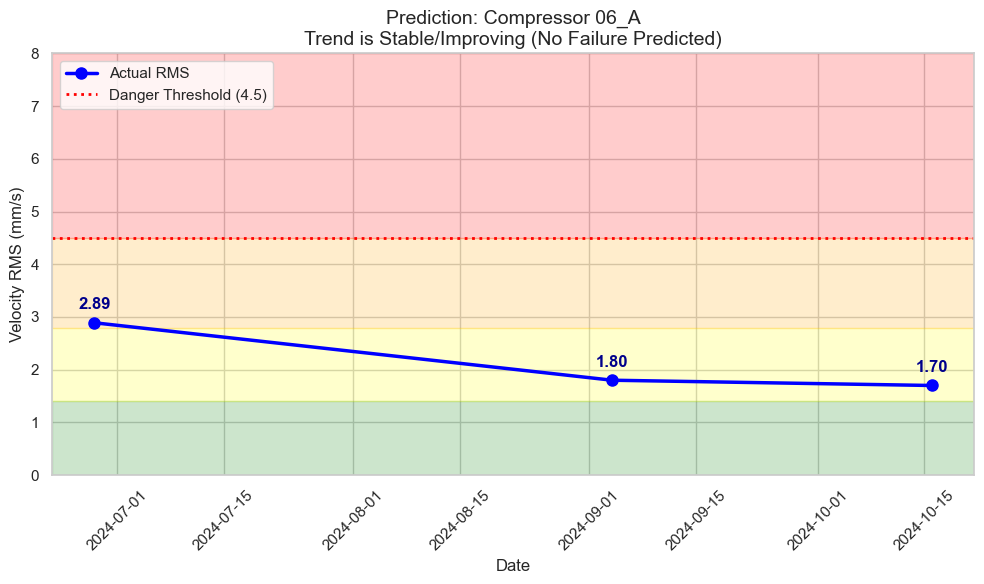

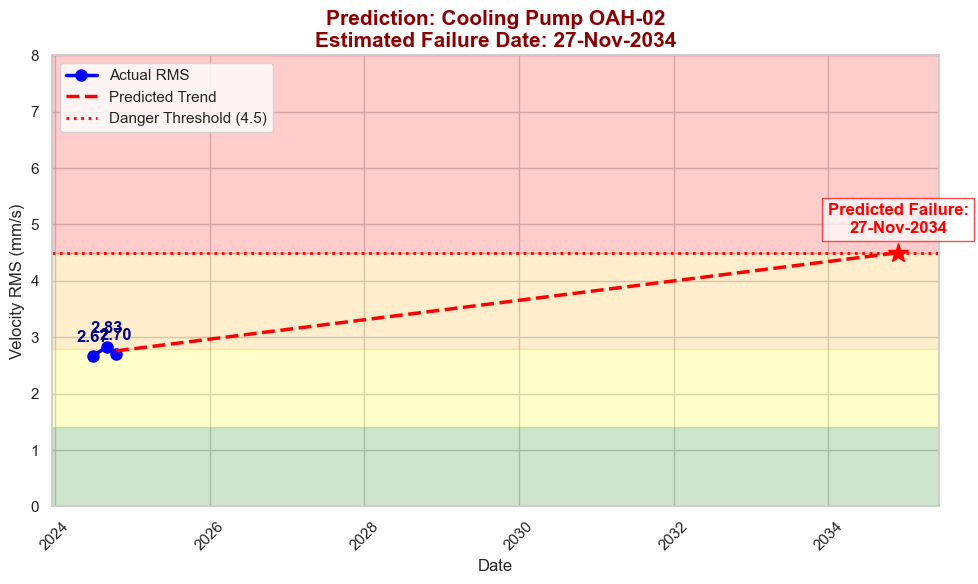

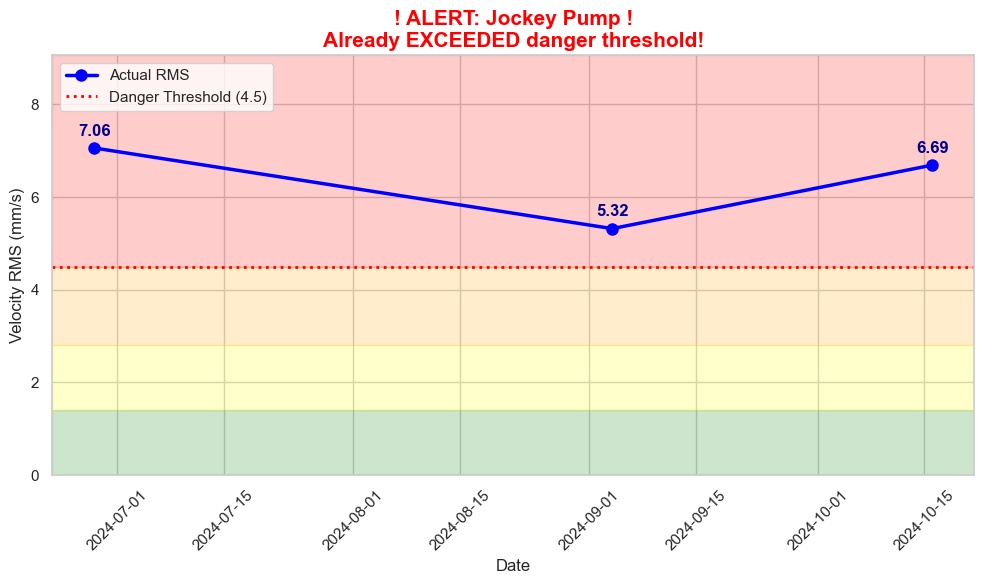

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")

def predict_and_plot_failure(df_summary, danger_threshold=4.5):
    """
    สร้างโมเดล Linear Regression พยากรณ์วันที่ค่าความสั่นจะทะลุ Danger Zone (4.5 mm/s)
    (อัปเดต: แก้ไข Logic ตรวจสอบค่าล่าสุดก่อนพยากรณ์)
    """
    equipments = df_summary['Equipment'].unique()
    
    for eq in equipments:
        df_eq = df_summary[df_summary['Equipment'] == eq].copy()
        
        # ต้องมีข้อมูลอย่างน้อย 2 จุด ถึงจะลากเส้นตรงได้
        if len(df_eq) < 2:
            print(f"⚠️ {eq}: มีข้อมูลไม่พอสำหรับทำนาย (ต้องการอย่างน้อย 2 เดือน)")
            continue
            
        plt.figure(figsize=(10, 6))
        
        # 1. แปลงวันที่เป็นตัวเลข (Ordinal) เพื่อให้ Machine Learning คำนวณได้
        X = df_eq['Date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
        y = df_eq['Velocity_RMS'].values
        
        # 2. สร้างและฝึกสอนโมเดล Linear Regression
        model = LinearRegression()
        model.fit(X, y)
        
        slope = model.coef_[0]
        intercept = model.intercept_
        
        # พล็อตกราฟข้อมูลจริงในอดีต (เส้นทึบสีน้ำเงิน)
        plt.plot(df_eq['Date'], df_eq['Velocity_RMS'], marker='o', linestyle='-', 
                 linewidth=2.5, markersize=8, color='blue', label='Actual RMS')
        
        # ใส่ Label ตัวเลขที่จุดจริง
        for date_val, rms_val in zip(df_eq['Date'], df_eq['Velocity_RMS']):
            plt.text(date_val, rms_val + 0.2, f'{rms_val:.2f}', 
                     ha='center', va='bottom', fontweight='bold', color='darkblue')

        # 🌟 ดึงค่า RMS ของเดือนล่าสุด (จุดสุดท้าย) มาเช็คก่อน
        latest_rms = df_eq['Velocity_RMS'].iloc[-1]
        
        # 3. วิเคราะห์สถานะและการพยากรณ์ (แก้ไข Logic แล้ว)
        if latest_rms >= danger_threshold:
            # ถ้ารอบล่าสุดทะลุเส้นแดงไปแล้ว ให้แจ้งเตือนวิกฤตทันที!
            plt.title(f'! ALERT: {eq} !\nAlready EXCEEDED danger threshold!', 
                      fontsize=15, fontweight='bold', color='red')
            
        elif slope <= 0:
            # ถ้ายังไม่ทะลุเส้นแดง และความชันติดลบ/เป็น 0 (ทรงตัวหรือดีขึ้น)
            plt.title(f'Prediction: {eq}\nTrend is Stable/Improving (No Failure Predicted)', fontsize=14)
            
        else:
            # 4. ถ้าค่ากำลังพุ่งขึ้น (ความชันเป็นบวก) ให้คำนวณหาวันพัง
            predicted_ordinal = (danger_threshold - intercept) / slope
            predicted_date = pd.Timestamp.fromordinal(int(predicted_ordinal))
            
            # สร้างจุดข้อมูลสำหรับเส้นพยากรณ์ (จากวันล่าสุด ถึง วันที่คาดว่าจะพัง)
            future_dates_ordinal = np.array([X[-1][0], predicted_ordinal]).reshape(-1, 1)
            future_rms = model.predict(future_dates_ordinal)
            future_dates = [pd.Timestamp.fromordinal(int(d[0])) for d in future_dates_ordinal]
            
            # พล็อตเส้นพยากรณ์ (เส้นประสีแดง)
            plt.plot(future_dates, future_rms, linestyle='--', linewidth=2.5, 
                     color='red', label='Predicted Trend')
            
            # ทำเครื่องหมายจุดที่คาดว่าจะพัง (ดาวสีแดงขนาดใหญ่)
            plt.plot(predicted_date, danger_threshold, marker='*', color='red', markersize=15)
            plt.text(predicted_date, danger_threshold + 0.3, f'Predicted Failure:\n{predicted_date.strftime("%d-%b-%Y")}', 
                     ha='center', va='bottom', fontweight='bold', color='red', 
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
            
            plt.title(f'Prediction: {eq}\nEstimated Failure Date: {predicted_date.strftime("%d-%b-%Y")}', 
                      fontsize=15, fontweight='bold', color='darkred')

        # 5. ระบายสีพื้นหลังตามเกณฑ์ ISO 10816-3 (Conservative)
        plt.axhspan(0, 1.4, color='green', alpha=0.2)
        plt.axhspan(1.4, 2.8, color='yellow', alpha=0.2)
        plt.axhspan(2.8, 4.5, color='orange', alpha=0.2)
        
        # เซ็ตขอบเขตแกน Y ให้สวยงาม
        top_y_limit = max(8.0, df_eq['Velocity_RMS'].max() + 2.0) 
        plt.axhspan(4.5, top_y_limit, color='red', alpha=0.2)
        
        # ตกแต่งกราฟ
        plt.axhline(y=danger_threshold, color='red', linestyle=':', linewidth=2, label='Danger Threshold (4.5)')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Velocity RMS (mm/s)', fontsize=12)
        plt.ylim(0, top_y_limit) 
        plt.xticks(rotation=45)
        
        # จัดตำแหน่ง Legend
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()

# ==========================================
# 🎯 ทดสอบการใช้งาน (รันฟังก์ชันโดยส่ง DataFrame จาก Step 3 เข้าไป)
# ==========================================
predict_and_plot_failure(df_final_summary)

## 📝 สรุป: การทำ Predictive Maintenance (Vibration Analysis & Failure Prediction)

จากการนำข้อมูลมาวิเคราะห์และสร้างแบบจำลองใน Step 5 เราสามารถสรุปประเด็นสำคัญและข้อควรระวังได้ดังนี้:

* **⏳ ข้อจำกัดเรื่องปริมาณข้อมูล (Data Volume):** จะสังเกตได้ว่าการใช้ Machine Learning อย่าง Linear Regression เพื่อลากเส้นพยากรณ์ล่วงหน้าจากข้อมูล Velocity RMS ที่เก็บมาเพียง 3 จุด (ช่วงเวลา 3 เดือน) นั้น **อาจจะยังไม่เพียงพอที่จะให้ผลลัพธ์การคาดเดาเวลาเสื่อมสภาพที่แม่นยำในระยะยาวได้** ในการใช้งานจริง ควรมีการเก็บข้อมูลที่ถี่ขึ้นหรือมีประวัติข้อมูลที่ยาวนานกว่านี้เพื่อให้โมเดลเรียนรู้แนวโน้มได้ดีขึ้น

* **⚙️ ข้อจำกัดเรื่องข้อมูลจำเพาะเครื่องจักร (Machine Specs):** ข้อมูลชุดนี้ไม่ได้ระบุ **กำลังไฟฟ้า (Rated Power - kW)** และประเภทฐานราก (Rigid/Flexible) ของมอเตอร์แต่ละตัวมาให้ ซึ่งเป็นตัวแปรสำคัญในการชี้วัดตามมาตรฐาน **ISO 10816-3** ในโปรเจกต์นี้จึงเลือกใช้วิธี **Conservative Approach** (อิงเกณฑ์กลุ่ม 15-300 kW ฐานแข็ง) ซึ่งเป็นเกณฑ์ที่เข้มงวดที่สุด (เส้นแดงขีดที่ 4.5 mm/s) เพื่อเน้นความปลอดภัยสูงสุดไว้ก่อน

* **🚨 การแจ้งเตือนสถานะวิกฤต (Actionable Insight):** ถึงแม้ข้อมูลจะมีข้อจำกัด แต่ระบบที่พัฒนาขึ้นก็สามารถชี้เป้าความผิดปกติได้อย่างชัดเจน โดยพบว่าปัจจุบันมีเครื่องจักรที่ค่าความสั่นสะเทือนทะลุเข้าสู่ **โซนอันตราย (Danger Zone)** ไปแล้ว 1 ตัว นั่นคือ **Jockey Pump** (ค่าล่าสุดพุ่งไปถึง 6.69 mm/s) ซึ่งข้อมูลนี้มีค่ามากเพียงพอให้ทีมวิศวกรสั่งหยุดเครื่องเพื่อตรวจสอบและวางแผนซ่อมบำรุงได้ทันที ก่อนที่จะเกิดความเสียหายร้ายแรงต่อระบบโรงงาน